Integration success: True
The solver successfully reached the end of the integration interval.
Final state: [-0.00021172  0.04494415 -0.15809582]


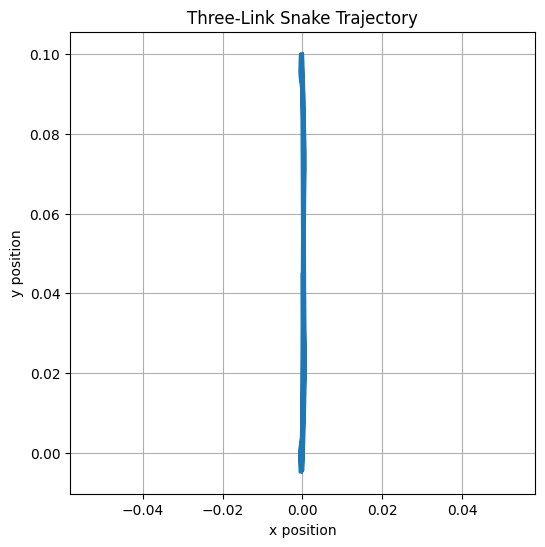

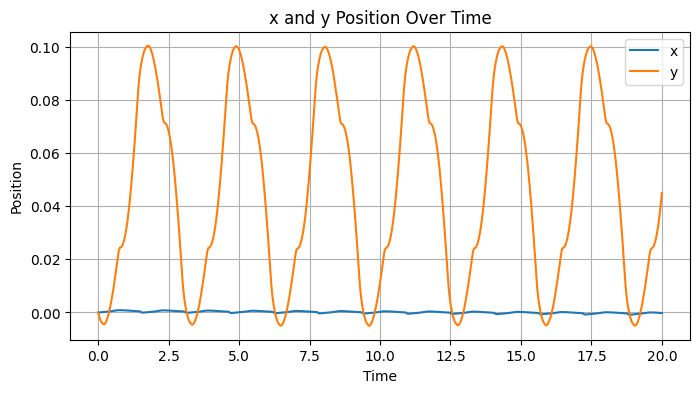

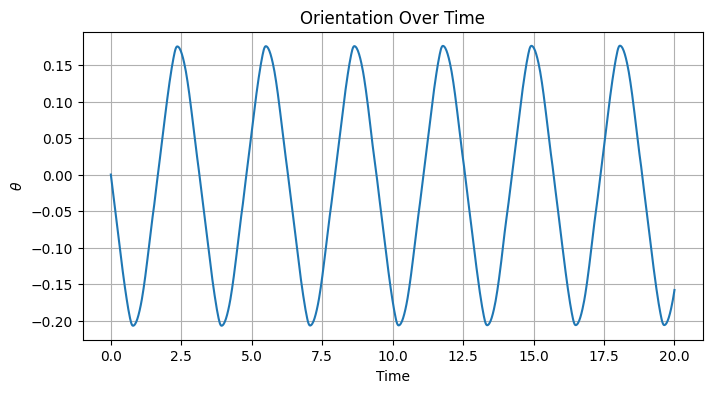

In [3]:
# Part 1
def snake_body_wrench(Vb, f_perp, f_par):
    epsilon = 1E-6
    # Vb is a body twist with wx, wy, wz, vx, vy, vz in body frame
    Fb = np.array([[0],
                   [0],
                   [0],
                   [0],
                   [0],
                   [0]])
    
    # Check if sliding forward/backward
    if np.abs(Vb[3]) < epsilon:
        Fb[3] = 0
    elif Vb[3] > 0:
        Fb[3] = -f_par
    else:
        Fb[3] = 2*f_par

    if np.abs(Vb[4]) < epsilon:
        Fb[4] = 0
    else:
        Fb[4] = -f_perp*np.sign(Vb[4])
        
    return Fb

def snake_body_wrench_smooth(Vb, f_perp, f_par):
    epsilon = 10
    # Vb is a body twist with wx, wy, wz, vx, vy, vz in body frame
    Fb = np.array([[0],
                   [0],
                   [0],
                   [0],
                   [0],
                   [0]])
    Fb[3] = -f_par*(1.5*np.tanh(epsilon*Vb[3]+.3)+.3)
    # Checking if sliding forward/backward
    Fb[4] = -f_perp*np.tanh(epsilon*Vb[4])

    return Fb 
    
# Part 2

from sympy import lambdify, symbols
l, w, m, A1, A2, omega, phi = symbols('l w m A1 A2 omega phi', real=True)

q = sp.Matrix([x, y, theta, alpha1, alpha2])
qd = q.diff(t)
qdd = q.diff(t, 2)

params = [l, w, m, A1, A2, omega, phi]

v_b_lambda = lambdify([q, qd, params], Vb_b)
v_1_lambda = lambdify([q, qd, params], Vb_1)
v_2_lambda = lambdify([q, qd, params], Vb_2)

J_b_lambda = lambdify([q, qd, params], Jb_b)
J_1_lambda = lambdify([q, qd, params], Jb_1)
J_2_lambda = lambdify([q, qd, params], Jb_2)

def net_force(q, qd, params, f_par, f_perp):
    F = J_b_lambda(q, qd, params).T @ snake_body_wrench_smooth(v_b_lambda(q, qd, params), f_par, f_perp) + \
        J_1_lambda(q, qd, params).T @ snake_body_wrench_smooth(v_1_lambda(q, qd, params), f_par, f_perp) + \
        J_2_lambda(q, qd, params).T @ snake_body_wrench_smooth(v_2_lambda(q, qd, params), f_par, f_perp) 
    return F